# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [3]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [2]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [3]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Write your code here to read the data
df = pd.read_csv('/content/drive/MyDrive/Python Course/FoodHub/foodhub_order.csv')

In [7]:
# Write your code here to view the first 5 rows
df.head(5)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [8]:
# Write your code here
df.shape
#This dataframe has 1898 rows and each row has 9 columns

(1898, 9)

#### Observations:



*   Total orders are 1898
*   Total attributes are 9




### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [42]:
# Write your code here
df.info()
#Dataframe info shows column name, number of null values and its data type for each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:


*   Data columns (total 9 columns)
*   #   Column                 Non-Null Count  Dtype  
*   ---  ------                 --------------  -----  
*   0   order_id               1898 non-null   int64  
*   1   customer_id            1898 non-null   int64  
*   2   restaurant_name        1898 non-null   object
*   3   cuisine_type           1898 non-null   object
*   4   cost_of_the_order      1898 non-null   float64
*   5   day_of_the_week        1898 non-null   object
*   6   rating                 1898 non-null   object
*   7   food_preparation_time  1898 non-null   int64  
*   8   delivery_time          1898 non-null   int64  
*   dtypes: float64(1), int64(4), object(4)
*   memory usage: 133.6+ KB



### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [43]:
# Write your code here
df.isnull().sum()
#there are no null values in any of the columns

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:

*   there are no null values in any of the columns

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [44]:
# Write your code here
df.describe()
# following shows the statistical summary of the data
# Minimum Food preperation time is - 20 minutes
# Max Food Preperation time is - 35 Minutes
# Average Food Preparation time is - 27.37 minutes

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


#### Observations:




*   following shows the statistical summary of the data
*   Minimum Food preperation time is - 20 minutes
*   Max Food Preperation time is - 35 Minutes
*   Average Food Preparation time is - 27.37 minutes



### **Question 5:** How many orders are not rated? [1 mark]

In [46]:
# Write the code here
no_rate_df = df[df['rating'].apply(lambda x: str(x).isnumeric() == False)]
no_rate_df.shape[0]
#total number of orders not rated 736

736

#### Observations: total number of orders not rated 736


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [87]:
#unique order ids
df['order_id'].unique()

array([1477147, 1477685, 1477070, ..., 1477819, 1477513, 1478056])

In [88]:
#unique customer ids
df['customer_id'].unique()

array([337525, 358141,  66393, ...,  97838, 292602, 397537])

In [89]:
#unique restaurant names
df['restaurant_name'].unique()

array(['Hangawi', 'Blue Ribbon Sushi Izakaya', 'Cafe Habana',
       'Blue Ribbon Fried Chicken', 'Dirty Bird to Go',
       'Tamarind TriBeCa', 'The Meatball Shop', 'Barbounia',
       'Anjappar Chettinad', 'Bukhara Grill',
       'Big Wong Restaurant \x8c_¤¾Ñ¼', 'Empanada Mama (closed)', 'Pylos',
       "Lucky's Famous Burgers", 'Shake Shack', 'Sushi of Gari',
       'RedFarm Hudson', 'Blue Ribbon Sushi',
       'Five Guys Burgers and Fries', 'Tortaria', 'Cafe Mogador',
       'Otto Enoteca Pizzeria', 'Vezzo Thin Crust Pizza',
       'Sushi of Gari 46', 'The Kati Roll Company', 'Klong',
       '5 Napkin Burger', 'TAO', 'Parm', 'Sushi Samba',
       'Haru Gramercy Park', 'Chipotle Mexican Grill $1.99 Delivery',
       'RedFarm Broadway', 'Cafeteria', 'DuMont Burger',
       "Sarabeth's East", 'Hill Country Fried Chicken', 'Bistango',
       "Jack's Wife Freda", "Mamoun's Falafel", 'Prosperity Dumpling',
       'Blue Ribbon Sushi Bar & Grill', 'Westville Hudson',
       'Blue Ribbon Br

In [90]:
#unique cuisine type
df['cuisine_type'].unique()

array(['Korean', 'Japanese', 'Mexican', 'American', 'Indian', 'Italian',
       'Mediterranean', 'Chinese', 'Middle Eastern', 'Thai', 'Southern',
       'French', 'Spanish', 'Vietnamese'], dtype=object)

<Axes: xlabel='cuisine_type', ylabel='count'>

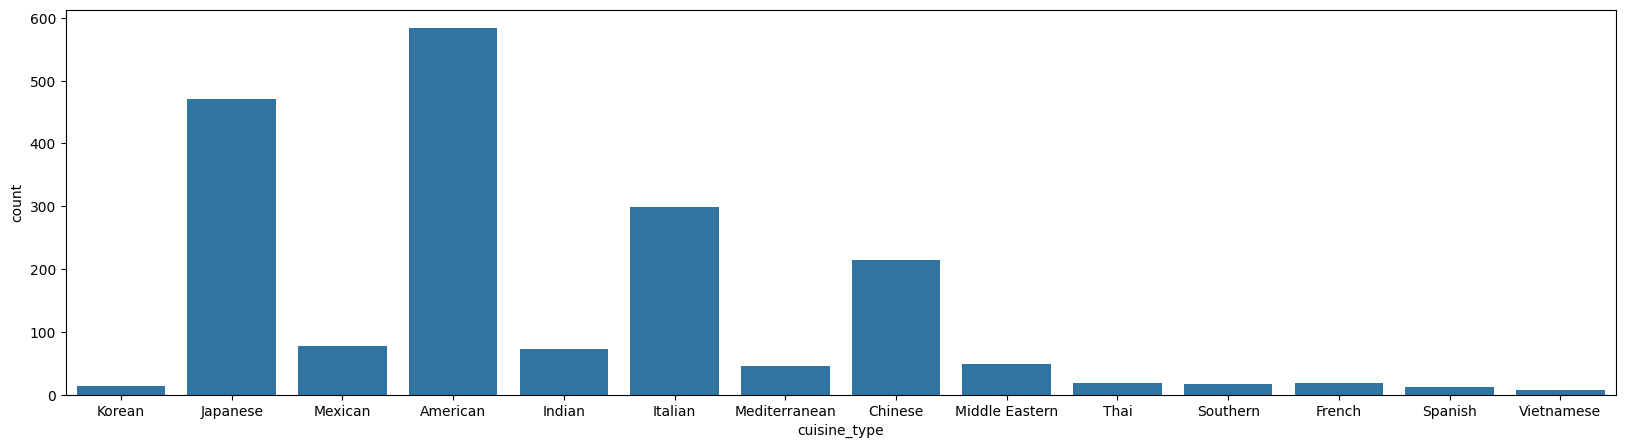

In [92]:
plt.figure(figsize = (20,5))
sns.countplot(data = df, x = 'cuisine_type')

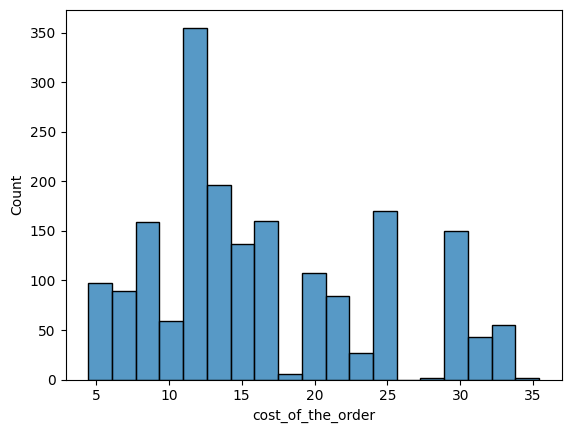

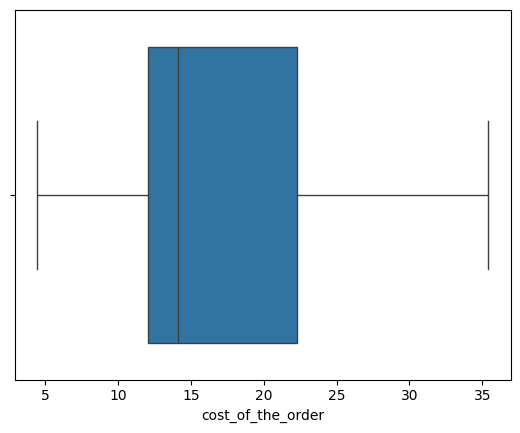

In [93]:
# cost of the order
sns.histplot(data=df,x='cost_of_the_order');
plt.show();
sns.boxplot(data=df,x='cost_of_the_order');
plt.show();


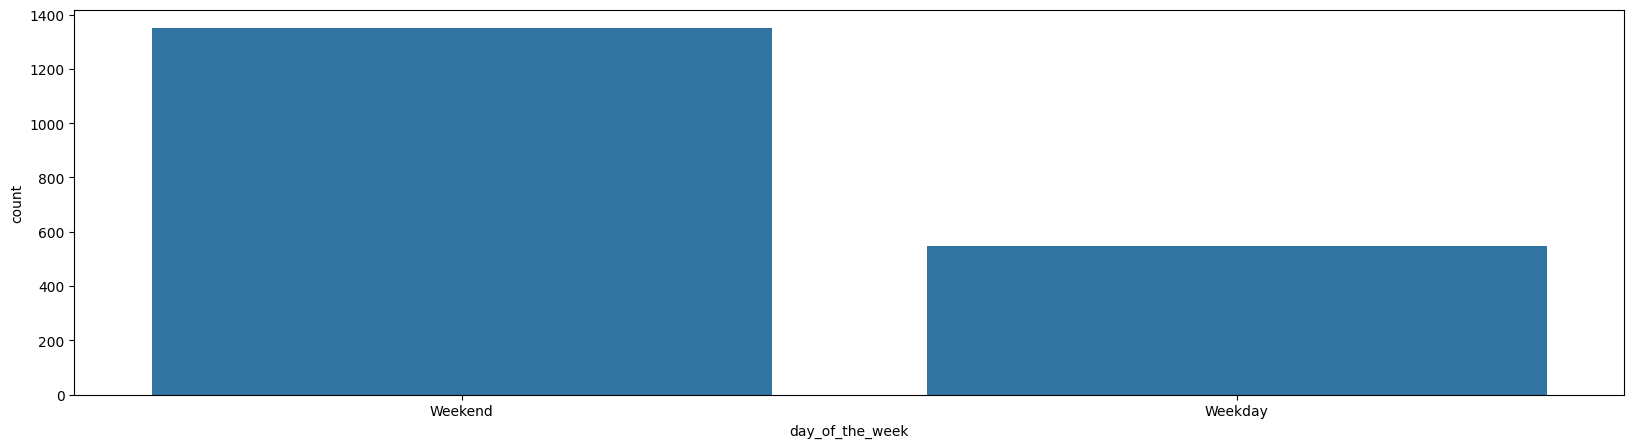

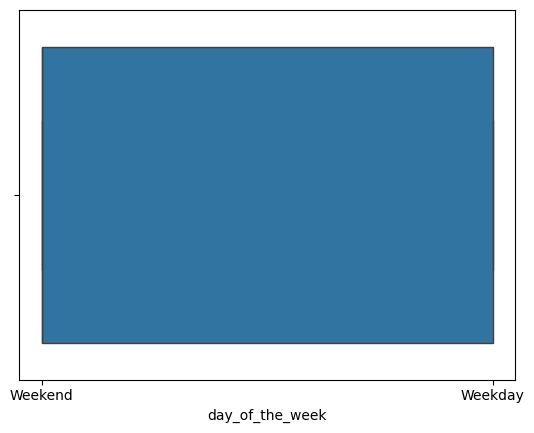

In [96]:
plt.figure(figsize = (20,5))
sns.countplot(data = df, x = 'day_of_the_week')
plt.show();


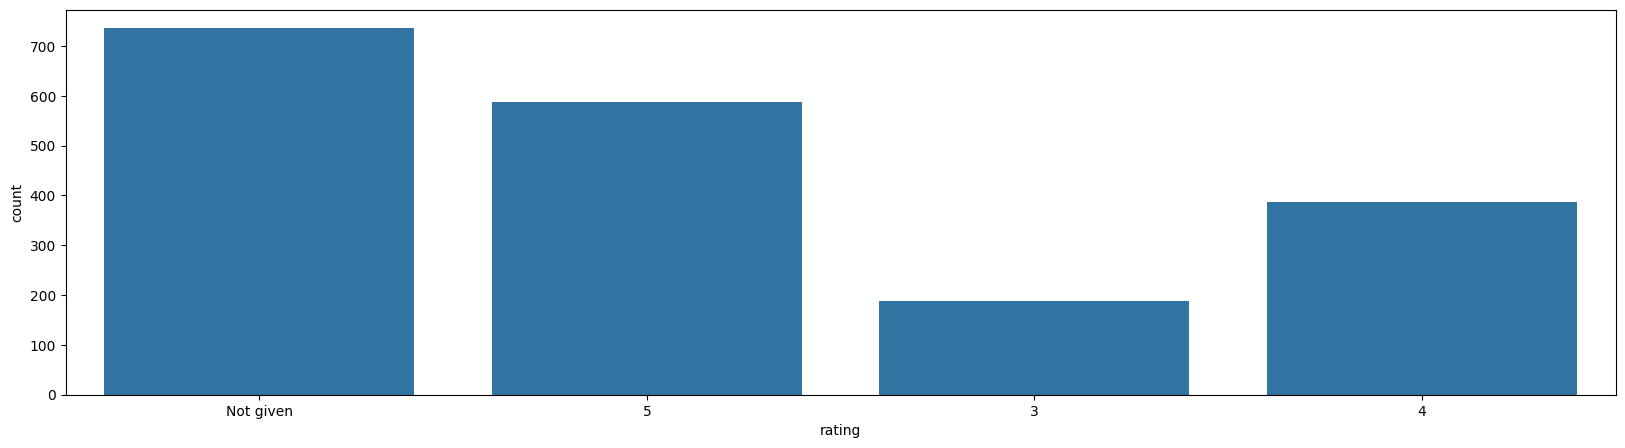

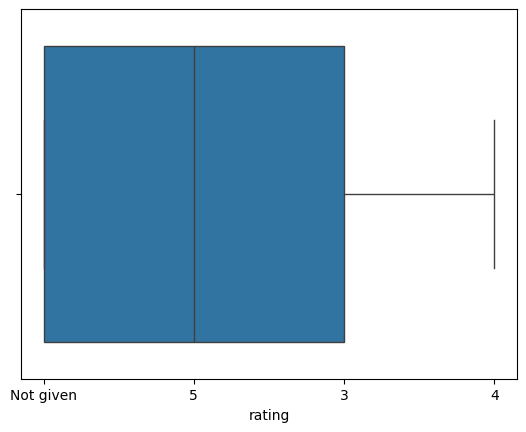

In [97]:
plt.figure(figsize = (20,5))
sns.countplot(data = df, x = 'rating')
plt.show();
sns.boxplot(data=df,x='rating');
plt.show();

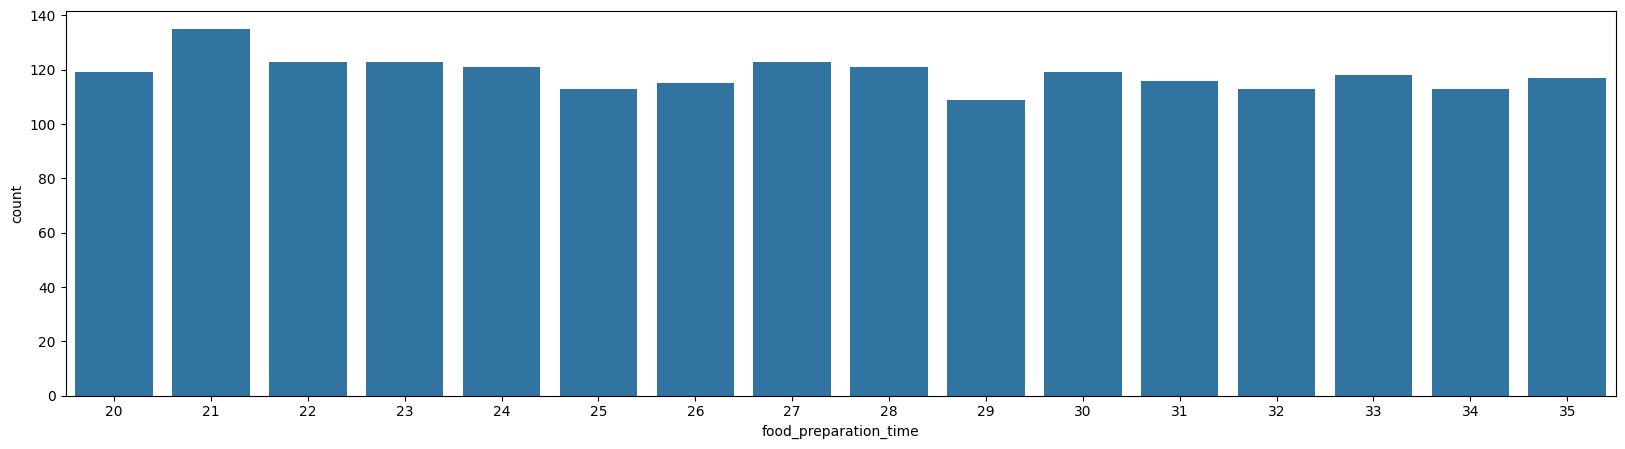

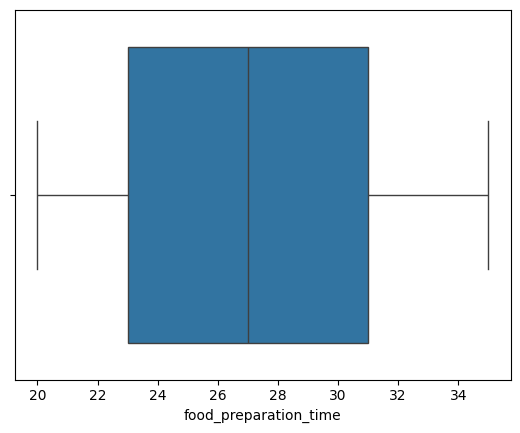

In [99]:
plt.figure(figsize = (20,5))
sns.countplot(data = df, x = 'food_preparation_time')
plt.show();
sns.boxplot(data=df,x='food_preparation_time');
plt.show();

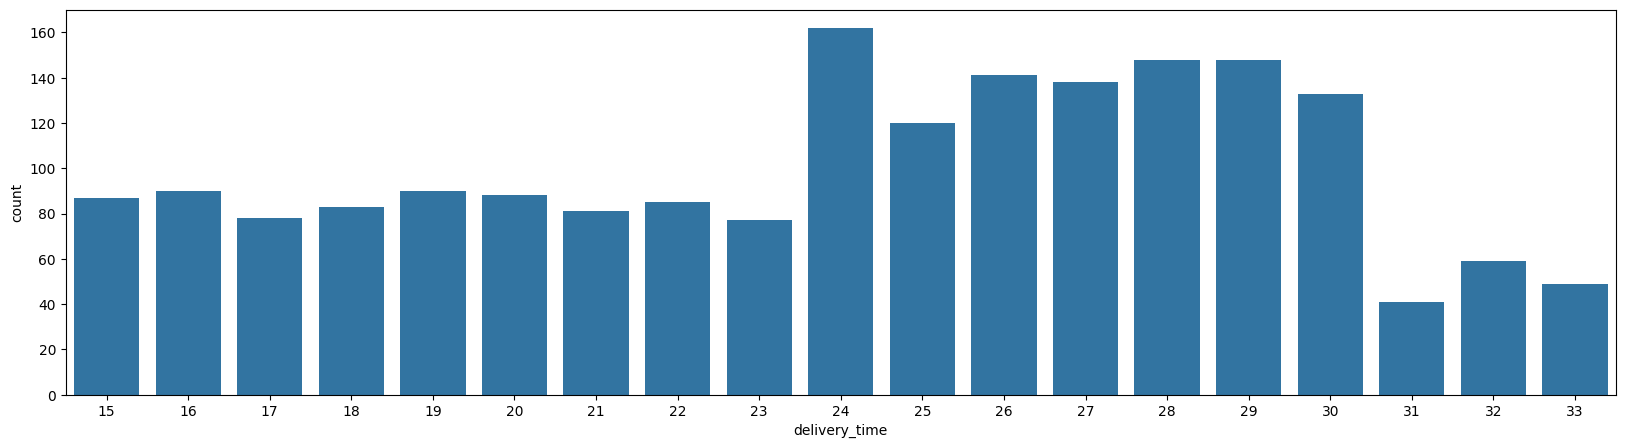

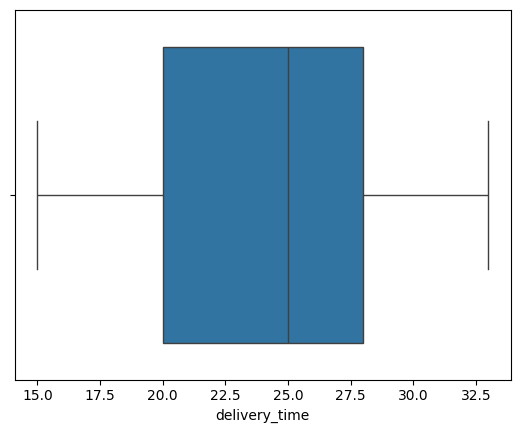

In [100]:
plt.figure(figsize = (20,5))
sns.countplot(data = df, x = 'delivery_time')
plt.show();
sns.boxplot(data=df,x='delivery_time');
plt.show();

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [86]:
# Write the code here
df['restaurant_name'].value_counts().head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations: Following are the top 5 restaurants


*   Shake Shack
*   The Meatball Shop
*   Blue Ribbon Sushi
*   Blue Ribbon Fried Chicken
*   Parm




### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [84]:
# Write the code here
df[df['day_of_the_week']=='Weekend']['cuisine_type'].value_counts().head(1)

,count
cuisine_type,
American,415


#### Observations:

*   American cuisine is most populare on weekends




### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [14]:
# Write the code here
df[df['cost_of_the_order']>20].shape[0]/df.shape[0]*100

29.24130663856691

#### Observations:

*   29.41% of orders cost more than $20




### **Question 10**: What is the mean order delivery time? [1 mark]

In [15]:
# Write the code here
print(df['delivery_time'].mean().round(2))

24.16


#### Observations:

*   Average delivery time is 24.16 minutes




### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [16]:
# Write the code here
df['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations: Following customer_ids eligible for 20% discount


*   52832
*   47440
*   83287




### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


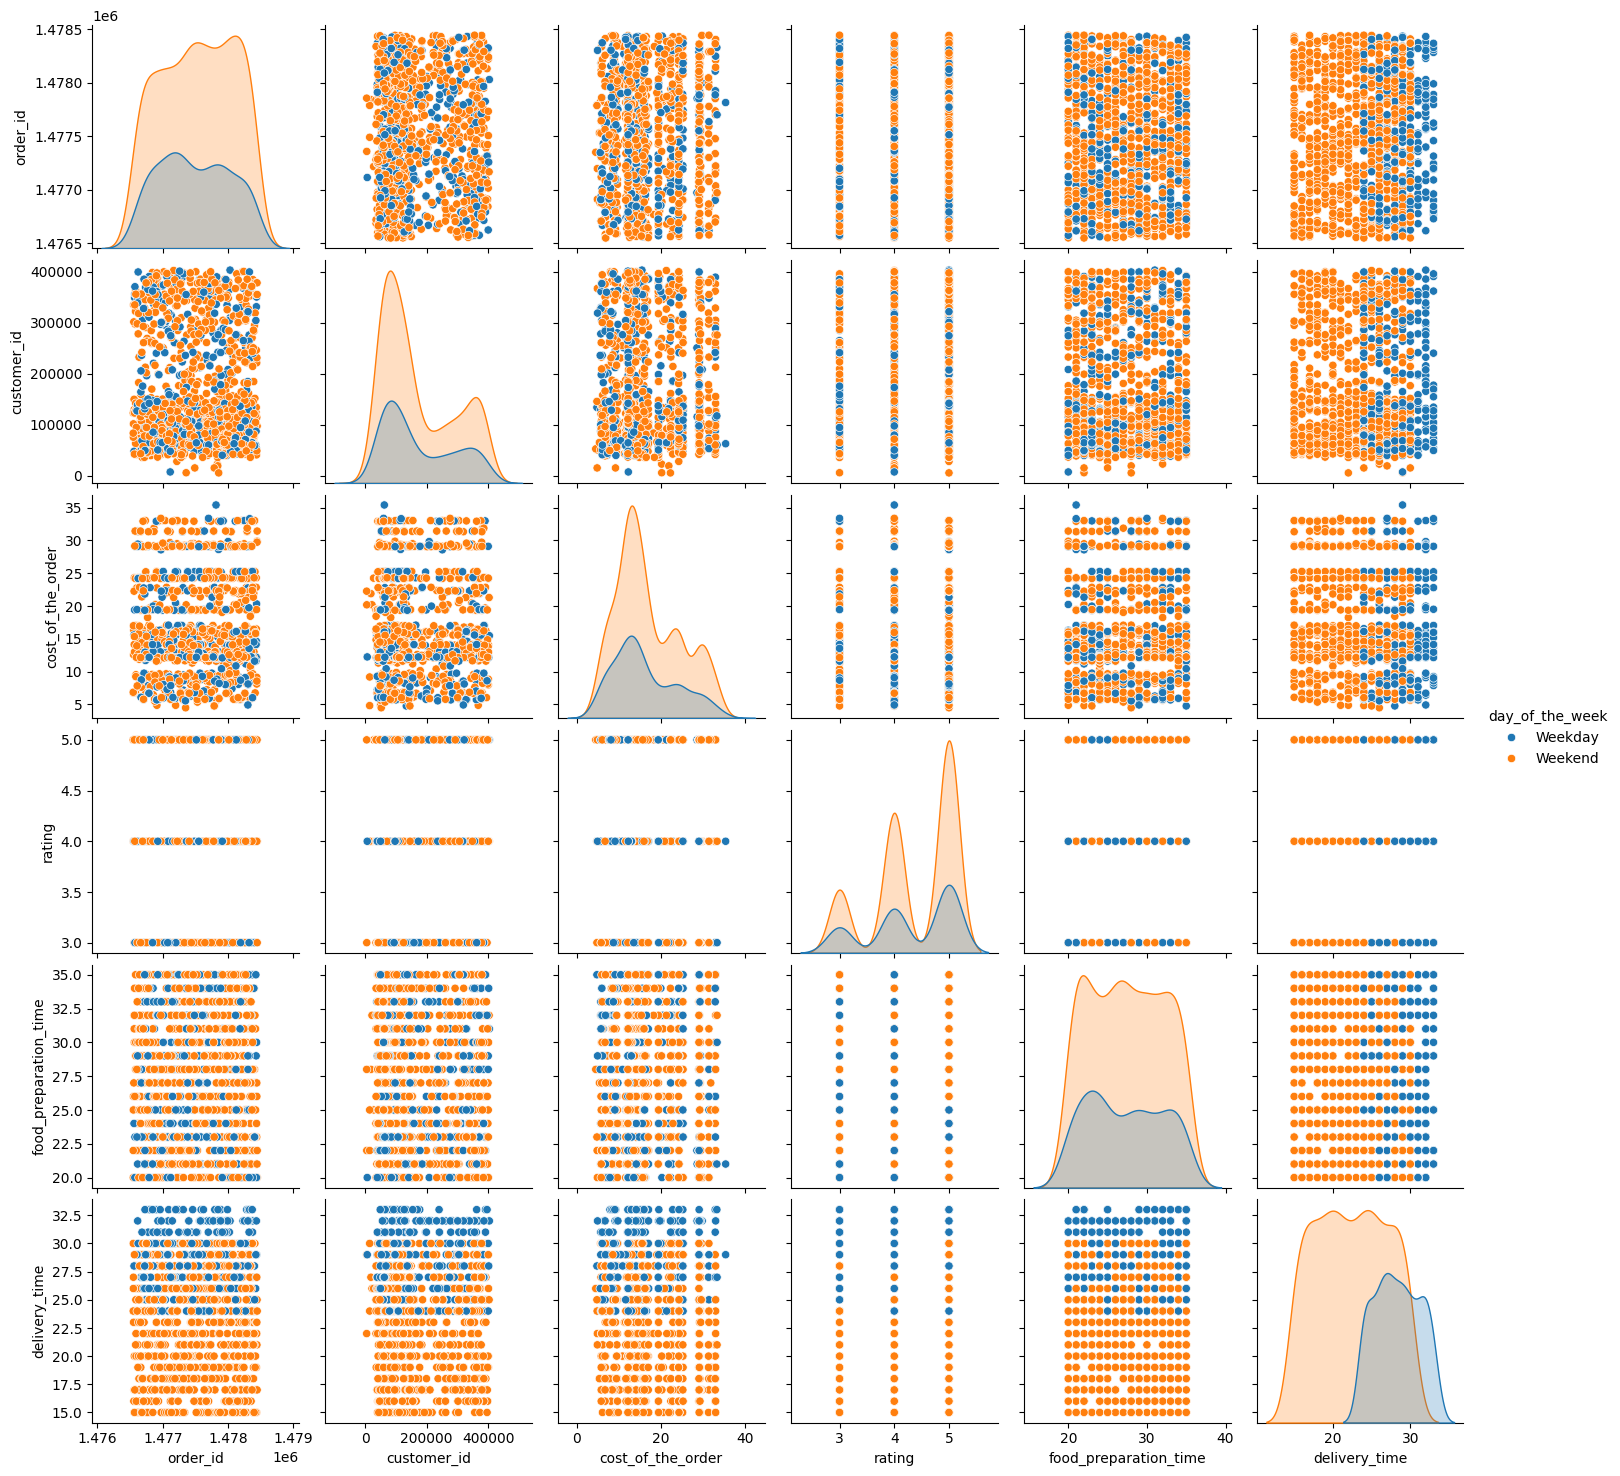

In [16]:
# Write the code here
df_rated = df[df['rating'].apply(lambda x: str(x).isnumeric())].copy()
df_rated['rating'] = pd.to_numeric(df_rated['rating'], errors='coerce')
sns.pairplot(data=df_rated,hue='day_of_the_week');
plt.show();

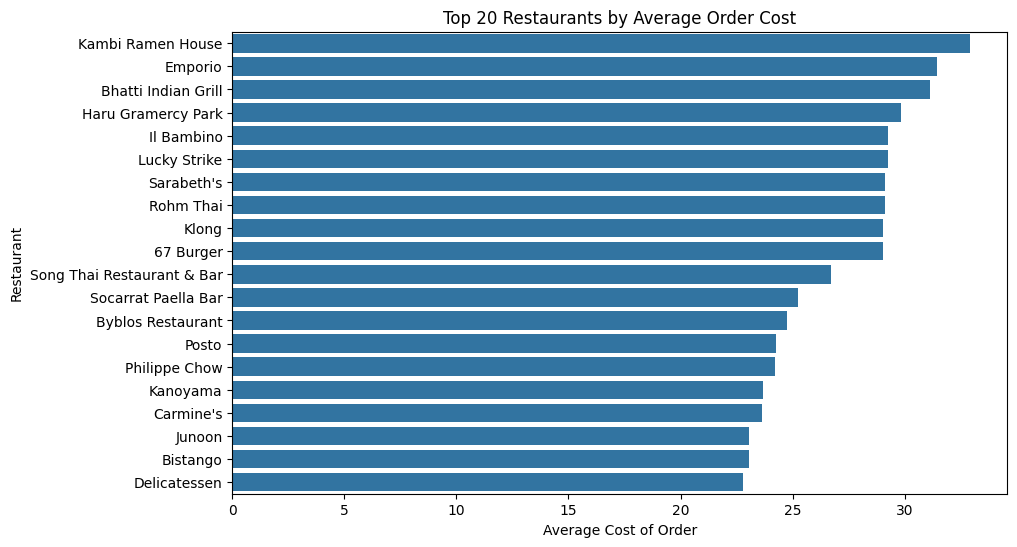

In [11]:
#restaurant vs cost of the order

# Relationship between day of the week and delivery time
df2 = df.copy()

restaurant_cost = df2.groupby('restaurant_name')['cost_of_the_order'].agg(
    avg_cost='mean',
    min_cost='min',
    max_cost='max',
    order_count='count'
).reset_index()

restaurant_cost.sort_values('avg_cost', ascending=False).head(10)

top20_expensive = restaurant_cost.sort_values('avg_cost', ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(data=top20_expensive, x='avg_cost', y='restaurant_name')
plt.title("Top 20 Restaurants by Average Order Cost")
plt.xlabel("Average Cost of Order")
plt.ylabel("Restaurant")
plt.show()



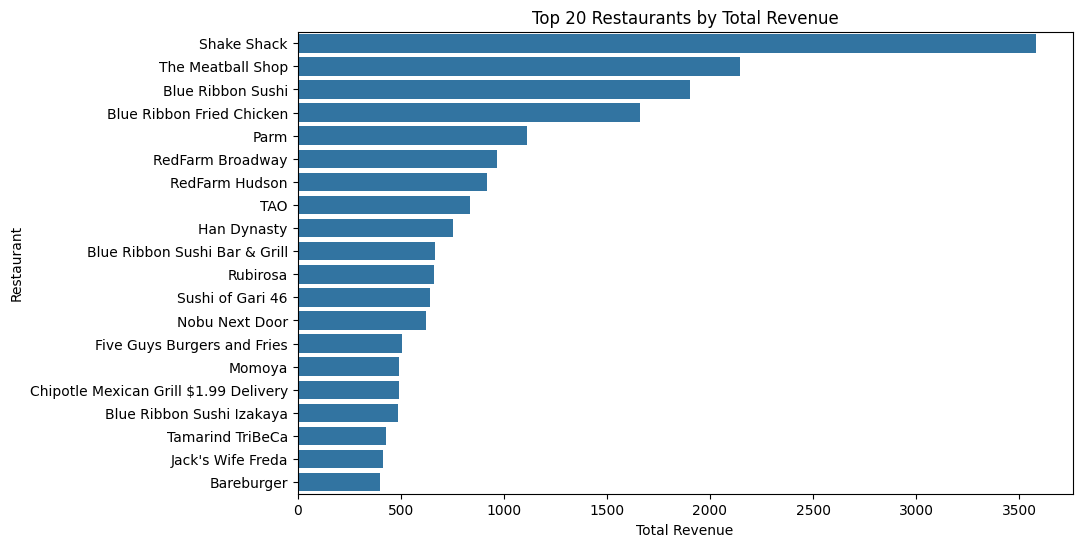

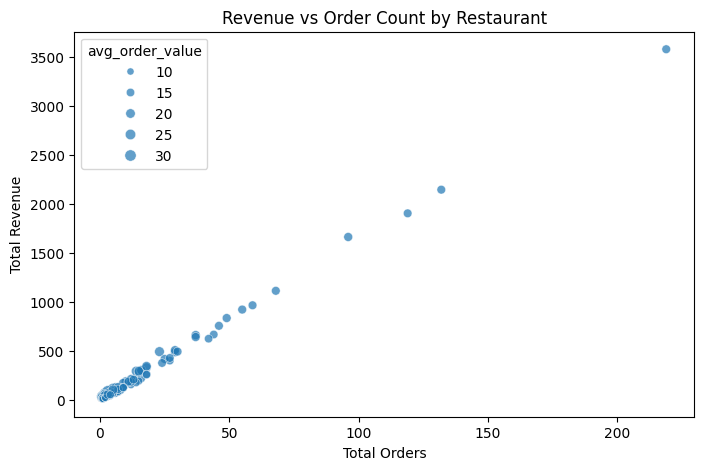

In [14]:
#total restaurant revenue analysis

restaurant_revenue = (
    df.groupby('restaurant_name')['cost_of_the_order']
    .sum()
    .reset_index(name='total_revenue')
    .sort_values('total_revenue', ascending=False)
)

top20 = restaurant_revenue.head(20)

plt.figure(figsize=(10,6))
sns.barplot(data=top20, x='total_revenue', y='restaurant_name')
plt.title("Top 20 Restaurants by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Restaurant")
plt.show()

#total revenue vs order count

restaurant_stats = df.groupby('restaurant_name').agg(
    total_revenue=('cost_of_the_order', 'sum'),
    order_count=('order_id', 'count'),
    avg_order_value=('cost_of_the_order', 'mean')
).reset_index()

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=restaurant_stats,
    x='order_count',
    y='total_revenue',
    size='avg_order_value',
    alpha=0.7
)
plt.title("Revenue vs Order Count by Restaurant")
plt.xlabel("Total Orders")
plt.ylabel("Total Revenue")
plt.show()


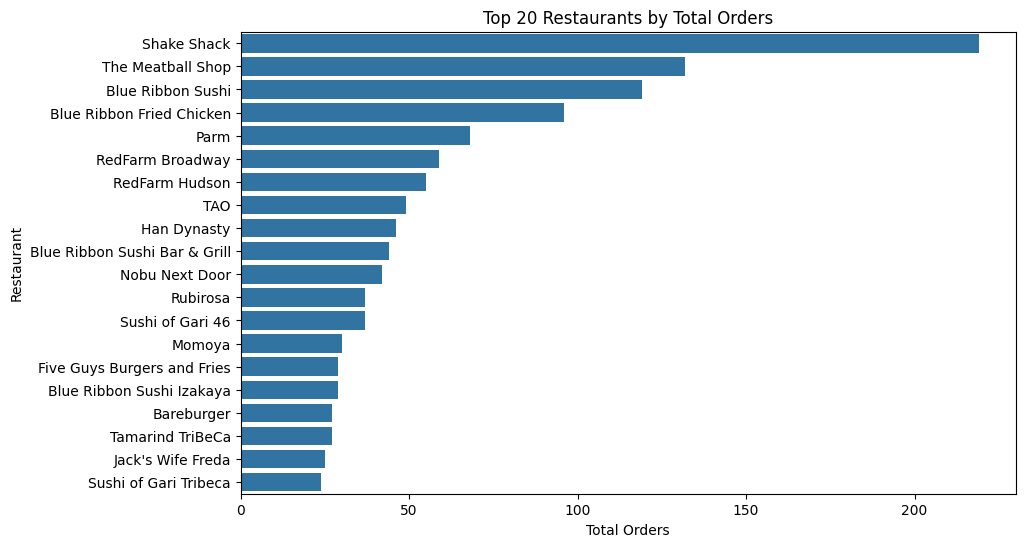

In [12]:
#total orders by restaurants

restaurant_orders = (
    df.groupby('restaurant_name')['order_id']
    .count()
    .reset_index(name='order_count')
    .sort_values('order_count', ascending=False)
)

restaurant_orders.head(10)   # Most orders
restaurant_orders.tail(10)   # Least orders

top20 = restaurant_orders.head(20)

plt.figure(figsize=(10,6))
sns.barplot(data=top20, x='order_count', y='restaurant_name')
plt.title("Top 20 Restaurants by Total Orders")
plt.xlabel("Total Orders")
plt.ylabel("Restaurant")
plt.show()


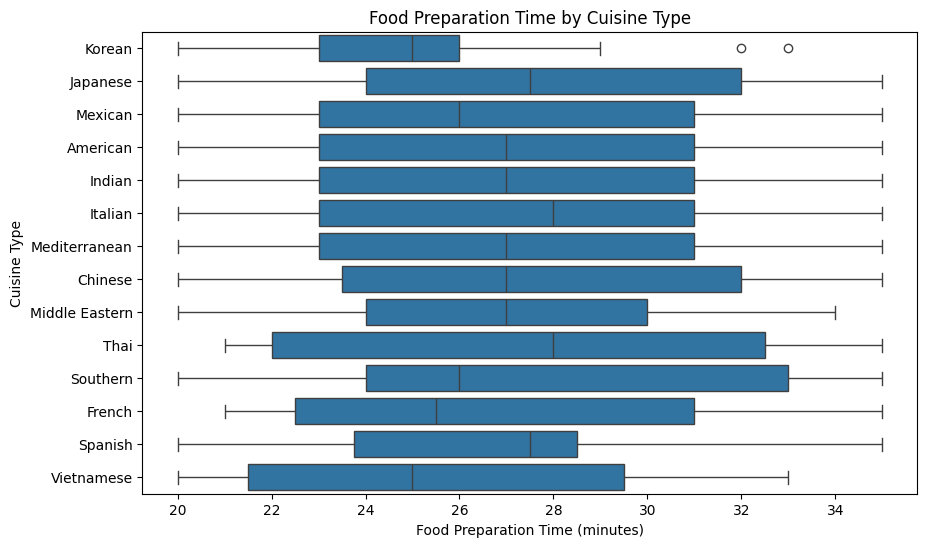

In [7]:
#cuisine vs food preperation time
cuisine_prep = df.groupby('cuisine_type')['food_preparation_time'].agg(
    avg_prep='mean',
    min_prep='min',
    max_prep='max',
    order_count='count'
).reset_index()

cuisine_prep.sort_values('avg_prep')

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='food_preparation_time', y='cuisine_type')
plt.title("Food Preparation Time by Cuisine Type")
plt.xlabel("Food Preparation Time (minutes)")
plt.ylabel("Cuisine Type")
plt.show()

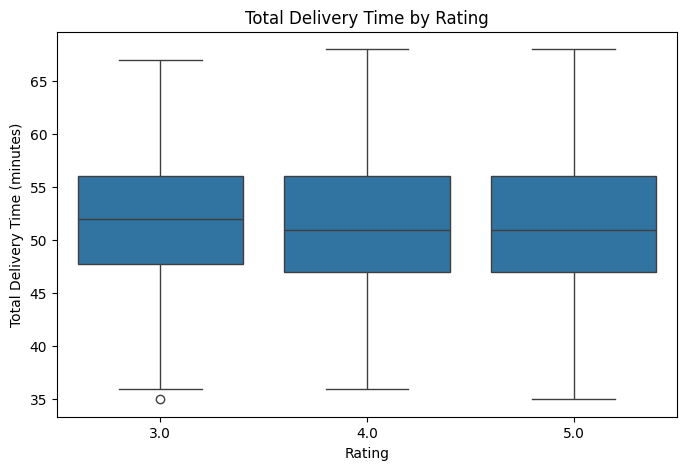

In [10]:
##rating vs total food delivery time


df2 = df.copy()

# Convert rating to numeric
df2['rating'] = pd.to_numeric(df2['rating'], errors='coerce')

# Drop invalid ratings
df2 = df2[df2['rating'].notna()]

# Create total delivery time by adding food preparation time and delivery time
df2['total_delivery_time'] = (
    df2['food_preparation_time'] + df2['delivery_time']
)

summary = df2.groupby('rating')['total_delivery_time'].agg(
    avg_time='mean',
    min_time='min',
    max_time='max',
    count='count'
).reset_index()

summary

plt.figure(figsize=(8,5))
sns.boxplot(data=df2, x='rating', y='total_delivery_time')

plt.title("Total Delivery Time by Rating")
plt.xlabel("Rating")
plt.ylabel("Total Delivery Time (minutes)")
plt.show()




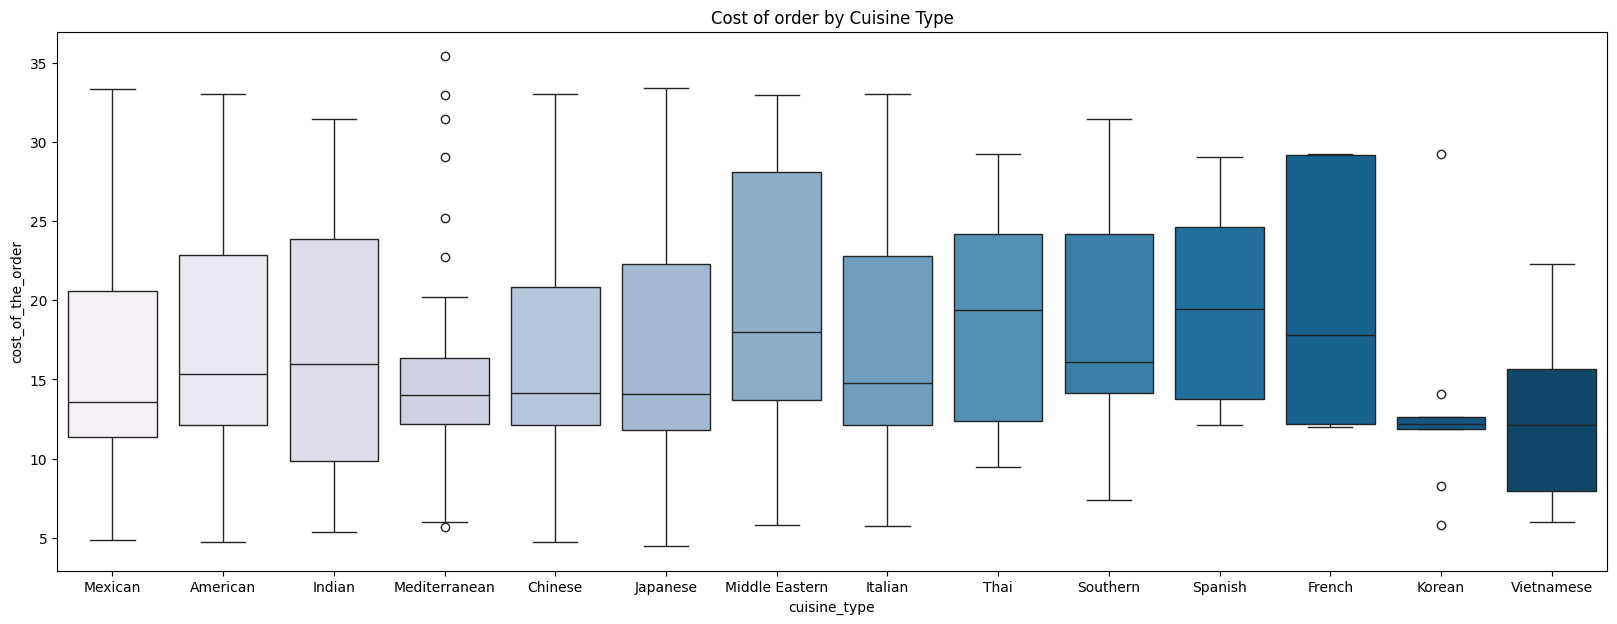

In [31]:
#cusine type vs cost of order
plt.figure(figsize=(20,7))
sns.boxplot(y='cost_of_the_order', x='cuisine_type' , data=df_rated, palette = 'PuBu', hue = 'cuisine_type' )

plt.title("Cost of order by Cuisine Type")
plt.suptitle("")   # removes automatic subtitle
plt.show()



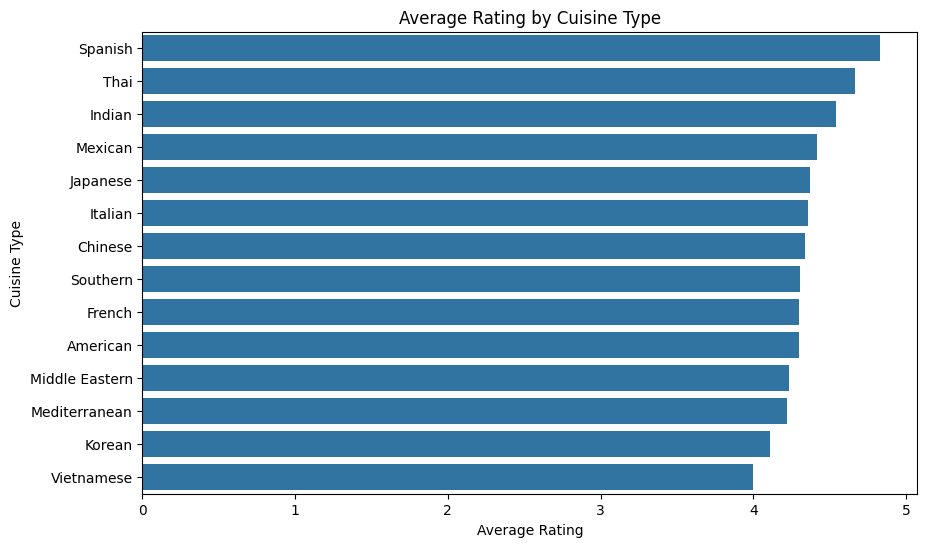

In [15]:
#cuisine vs rating

df2 = df.copy()
df2['rating'] = pd.to_numeric(df2['rating'], errors='coerce')
df2 = df2[df2['rating'].notna()]

cuisine_rating = df2.groupby('cuisine_type')['rating'].agg(
    avg_rating='mean',
    min_rating='min',
    max_rating='max',
    count='count'
).reset_index().sort_values('avg_rating', ascending=False)

cuisine_rating

plt.figure(figsize=(10,6))
sns.barplot(data=cuisine_rating, x='avg_rating', y='cuisine_type')
plt.title("Average Rating by Cuisine Type")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine Type")
plt.show()


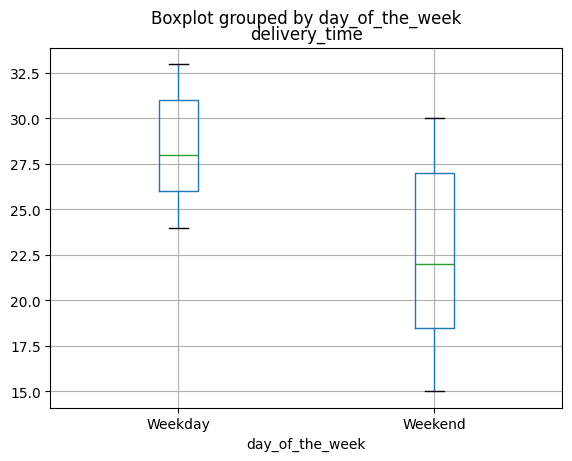

In [30]:
# delivery time vs day of the week
df.boxplot(column='delivery_time', by='day_of_the_week')
plt.show()

In [18]:
#average delivery time by restaurant

restaurant_stats = (
    df.groupby(['restaurant_name', 'cuisine_type'])
      .agg(
          avg_delivery_time=('delivery_time', 'mean'),
          total_orders=('order_id', 'count'),
          avg_order_cost=('cost_of_the_order', 'mean')
      )
      .reset_index()
      .sort_values('total_orders', ascending=False)
)



restaurant_stats.head(10)


,restaurant_name,cuisine_type,avg_delivery_time,total_orders,avg_order_cost
136,Shake Shack,American,24.662100,219,16.344886
21,Blue Ribbon Sushi,Japanese,23.941176,119,15.999580
154,The Meatball Shop,Italian,24.250000,112,16.259018
20,Blue Ribbon Fried Chicken,American,24.145833,96,17.315521
109,Parm,Italian,25.500000,68,16.364118
121,RedFarm Broadway,Chinese,23.152542,59,16.358136
122,RedFarm Hudson,Chinese,24.200000,55,16.749273
145,TAO,Japanese,23.163265,49,17.030612
66,Han Dynasty,Chinese,23.152174,46,16.419348
22,Blue Ribbon Sushi Bar & Grill,Japanese,23.409091,44,15.150455


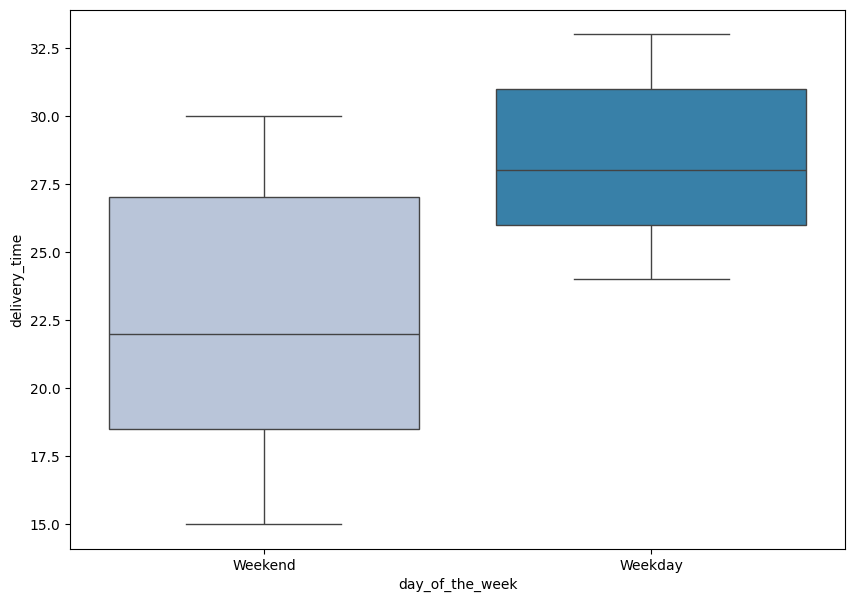

In [24]:
#day of the week vs delivery time
plt.figure(figsize=(10,7))
sns.boxplot(y='delivery_time', x='day_of_the_week' , data=df, palette = 'PuBu', hue = 'day_of_the_week' )
plt.show()


In [ ]:
#day of the week vs cost of order

In [11]:
df.groupby('day_of_the_week')['cost_of_the_order'].mean()


,cost_of_the_order
day_of_the_week,
Weekday,16.311188
Weekend,16.574833


### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [81]:
# Write the code here
#filter out records where rating is not int
df_rated = df[df['rating'].apply(lambda x: str(x).isnumeric())].copy()
# find rating count
# first group by restaurant_name and rating
#transform the count so that all ratings are preserved and rating count for each restaurant is added as an addition column called rating_count
df_rated['rating_count'] = df_rated.groupby('restaurant_name')['rating'].transform('count')

#convert rating type to int
df_rated['rating'] = pd.to_numeric(df['rating'], errors='coerce').astype('Int64')

#calculate the average rating for each restaurant
df_rated['average_rating'] = df_rated.groupby('restaurant_name')['rating'].transform('mean')

# find restaurants having rating count more than 50 and average rating greater than 4
df_discount = df_rated[(df_rated['rating_count']>50) & (df_rated['average_rating']>4)].copy()


top_restaurants = df_discount[['restaurant_name', 'average_rating', 'rating_count']].drop_duplicates()

print("total restaurants eligible for discount =  " , top_restaurants.shape[0])

#display 5 top restaurants receiving discount
top_restaurants.head(5)



#find restaurants having rating count more than 50


total restaurants eligible for discount =   4


,restaurant_name,average_rating,rating_count
3,Blue Ribbon Fried Chicken,4.328125,64
15,Shake Shack,4.278195,133
19,Blue Ribbon Sushi,4.219178,73
26,The Meatball Shop,4.511905,84


#### Observations: There are total 4 restaurants eligible for promotion offer


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [19]:
# Write the code here
#get orders costing more than 20 dollars
restaurant_greater_than_20 = df[df['cost_of_the_order'] > 20.0]
#get orders costing more than 5 dollars
restaurant_greater_than_5 = df[df['cost_of_the_order'] > 5]
#first calculate the total cost of the orders across all orders
total_cost = df['cost_of_the_order'].sum()
#add 25% charge on orders cost more than 20 dollars
cost_surcharge = restaurant_greater_than_20['cost_of_the_order'].sum() * 0.25
#add 15% charge on orders cost more than 5 dollars
cost_surcharge += restaurant_greater_than_5['cost_of_the_order'].sum() * 0.15
total_revenue = cost_surcharge
print(total_revenue)

5289.336


#### Observations: Total revenue generated across all orders is $5289.336


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [20]:
# Write the code here
df['total_delivery_time'] = df['food_preparation_time'] + df['delivery_time']
#total time to deliver the food
print("total time to deliver the food " , df['total_delivery_time'].sum())
#percentage of orders that take more than 60 minutes to get delivered
percentage_more_than60 = df[df['total_delivery_time']>60].shape[0]/df.shape[0]*100
print("Total percentage of orders taking more than 60 minutes ", percentage_more_than60)

total time to deliver the food  59884
Total percentage of orders taking more than 60 minutes  10.240963855421686


#### Observations:


*   total time to deliver the food  59884
*   Total percentage of orders taking more than 60 minutes  10.24%




### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [21]:
# Write the code here
df.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.305882
Weekend,22.436740


#### Observations:


*   Weekday Delivery time is 28.3 minutes
*   Weekend delivery time is 22.43 minutes




### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  There are more orders placed during the Weekends than weekdays
*  Delivery times on weekdays are higher than on Weekends
*  cost of the order has remained same during weekdays and weekends
*  Delivery times have no impact on the rating
*  Spanish cuisine has received highest rating
*  Cost of order is highest for French Cusine
*  10% of orders take more than 60 minutes to deliver
*  Shake Shak restaurant delivered most orders and also generated most revenue
*  Kambi Ramen house is the most costliest restaurant
*  American cusine is most popular and cost of order and delivery time have no impact on the number of orders placed
*  Rating is missing for many orders
*  Most orders placed are in range of $10 to $15 range

### Recommendations:

*  Incentivize users to provide rating for improved customer service
*  Improve the delivery time during the weekdays to improve the orders
*  Reduce the order cost or give discounts during weekdays to improve the number of orders
*  

In [19]:
!jupyter nbconvert --to html Full_Code.ipynb

[NbConvertApp] WARNING | pattern 'Full_Code.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    E

---